In [ ]:
# pitcher name
FIRST_NAME = "Kevin"
LAST_NAME = "Gausman"

# Season and date range
SEASON = 2025
START_DATE = f"{SEASON}-03-27"
END_DATE   = f"{SEASON}-09-28"

# Force refresh Statcast cache
FORCE_REFRESH = False

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pybaseball import statcast_pitcher, playerid_lookup

# creates cache folder
CACHE_DIR = "statcast_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


In [7]:
# find Statcast ID for player entered above

def lookup_statcast_id(first_name, last_name):
    lookup = playerid_lookup(last_name, first_name)

    if lookup.empty:
        raise ValueError("Player not found. Check spelling.")

    player_id = int(lookup.iloc[0]["key_mlbam"])
    print(f"Statcast ID found for {first_name} {last_name}: {player_id}")

    return player_id


PLAYER_ID = lookup_statcast_id(FIRST_NAME, LAST_NAME)


Statcast ID found for Kevin Gausman: 592332


In [8]:
# data pulled and saved
# creates a new file in statcast_cache with a change in player name or date

def get_statcast_data_cached(player_id, start_date, end_date, force_refresh=False):

    filename = f"{CACHE_DIR}/{LAST_NAME}_{start_date}_{end_date}.csv"

    if os.path.exists(filename) and not force_refresh:
        print("Loading Statcast data from cache...")
        return pd.read_csv(filename)

    print("Downloading Statcast data...")
    df = statcast_pitcher(start_date, end_date, player_id)

    if df.empty:
        raise ValueError("No Statcast data returned.")

    df.to_csv(filename, index=False)
    print(f"Saved cache file: {filename}")

    return df


df = get_statcast_data_cached(
    PLAYER_ID,
    START_DATE,
    END_DATE,
    force_refresh=FORCE_REFRESH
)


Gathering Player Data
Saved cache file: statcast_cache/Gausman_2025-03-27_2025-09-28.csv


In [ ]:
# switch game date column into datetime
df["game_date"] = pd.to_datetime(df["game_date"])

# filter to four-seam fastballs
df_ff = df[df["pitch_type"] == "FF"].copy()

# group four-seam fastball pitches by game date
df_daily = (
    df_ff
    .groupby("game_date")["release_speed"]
    .mean()
    .reset_index()
    .sort_values("game_date")
)


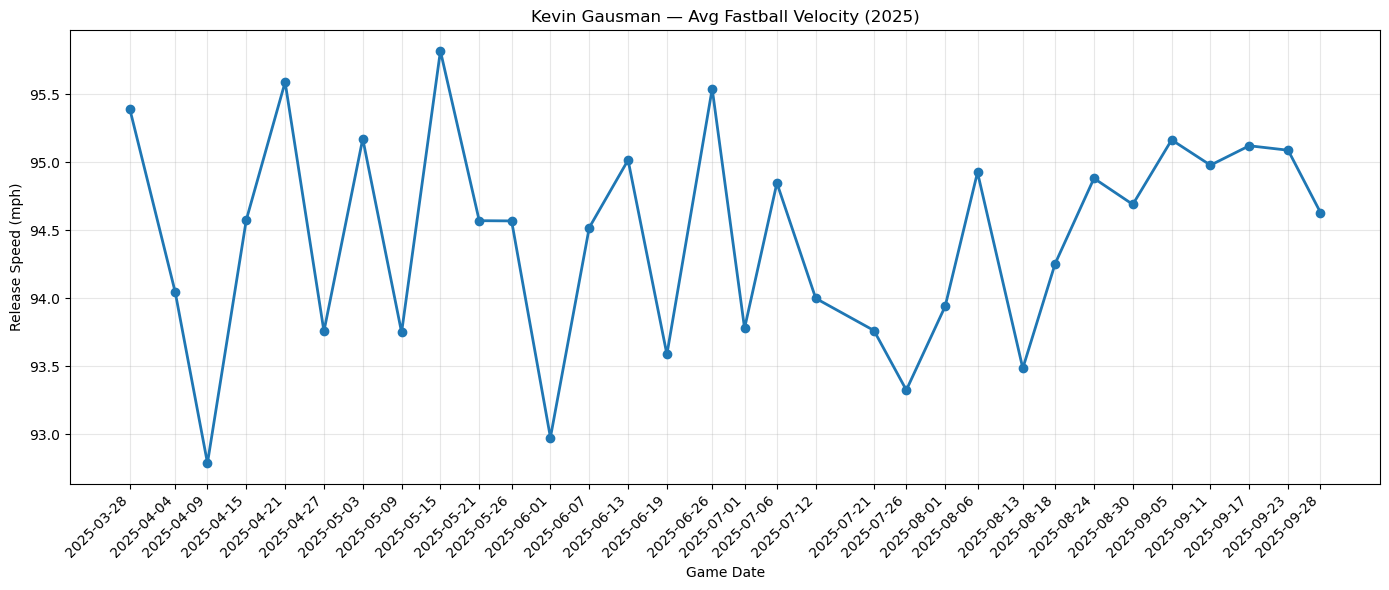

In [11]:
# =========================
# LINE GRAPH (WITH GAME DATES)
# =========================

plt.figure(figsize=(14, 6))

plt.plot(
    df_daily["game_date"],
    df_daily["release_speed"],
    marker="o",
    linewidth=2
)

plt.title(f"{FIRST_NAME} {LAST_NAME} — Avg Fastball Velocity ({SEASON})")
plt.xlabel("Game Date")
plt.ylabel("Release Speed (mph)")

# Explicitly show game dates on x-axis
plt.xticks(
    ticks=df_daily["game_date"],
    labels=df_daily["game_date"].dt.strftime("%Y-%m-%d"),
    rotation=45,
    ha="right"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
